In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [42]:
df_main = pd.read_csv("../data/FINAL_GRAVITY_TRAINING_MATRIX.csv")

In [43]:
df_main.head()

,orig,dest,cod_d,year0,cod_o,flow,iso3.x,P_it,PSR_i,IMR_it,...,gdp_d,gdp_d_lag,LA_j,LL_j,D_ij,LB_ij,OL_ij,COL_ij,t_2000,t_2000_sq
0,ABW,AFG,4,1990,533,0,ABW,62.152,8.855401,0.019028,...,NaN,NaN,652225.0,1.0,13257.81,0.0,0.0,0.0,-10,100
1,ABW,AFG,4,1995,533,0,ABW,80.324,10.075261,0.018687,...,NaN,NaN,652225.0,1.0,13257.81,0.0,0.0,0.0,-5,25
2,ABW,AFG,4,2000,533,0,ABW,90.866,9.141363,0.018008,...,3.521418e+09,NaN,652225.0,1.0,13257.81,0.0,0.0,0.0,0,0
3,ABW,AFG,4,2005,533,0,ABW,100.028,8.145069,0.016373,...,6.203257e+09,5.224897e+09,652225.0,1.0,13257.81,0.0,0.0,0.0,5,25
4,ABW,AFG,4,2010,533,0,ABW,101.665,6.691366,0.014963,...,1.585667e+10,1.241615e+10,652225.0,1.0,13257.81,0.0,0.0,0.0,10,100


In [44]:
# 1. Nombre d'années différentes
nb_annees = df_main['year0'].nunique()

# 2. Nombre total de lignes
nb_lignes = len(df_main)  # ou df_main.shape[0]

# 3. Nombre de codes ISO numériques différents (Origine)
nb_iso = df_main['orig'].nunique()

print(f"Années distinctes      : {nb_annees}")
print(f"Nombre total de lignes : {nb_lignes:,}")
print(f"Codes ISO uniques      : {nb_iso}")

# Bonus : Voir quelles sont les années disponibles
print("Liste des années :", df_main['year0'].unique())

Années distinctes      : 6
Nombre total de lignes : 229,350
Codes ISO uniques      : 199
Liste des années : [1990 1995 2000 2005 2010 2015]


In [45]:
df_main.describe()

,cod_d,year0,cod_o,flow,P_it,PSR_i,IMR_it,urban_it,gdp_o,gdp_o_lag,...,gdp_d,gdp_d_lag,LA_j,LL_j,D_ij,LB_ij,OL_ij,COL_ij,t_2000,t_2000_sq
count,229350.000000,229350.000000,229350.000000,2.293500e+05,2.293500e+05,229350.000000,229350.000000,222330.000000,2.182600e+05,2.145930e+05,...,2.182600e+05,2.145930e+05,2.193810e+05,219381.000000,209814.000000,209814.000000,209814.000000,209814.000000,229350.000000,229350.000000
mean,428.947874,2002.679398,428.947874,2.102040e+03,3.219870e+04,12.921026,0.034569,54.705724,2.475372e+11,2.408408e+11,...,2.475372e+11,2.408408e+11,6.937330e+05,0.191995,8013.624444,0.015843,0.155938,0.010981,2.679398,80.407238
std,250.822573,8.557358,250.822573,2.636109e+04,1.257890e+05,9.343365,0.034134,23.429666,1.104562e+12,1.066560e+12,...,1.104562e+12,1.066560e+12,1.933117e+06,0.393870,4507.412189,0.124867,0.362798,0.104214,8.557358,76.083518
min,4.000000,1990.000000,4.000000,0.000000e+00,6.215200e+01,2.344076,0.001258,5.274941,3.653429e+07,3.764532e+07,...,3.653429e+07,3.764532e+07,2.500000e+01,0.000000,59.617230,0.000000,0.000000,0.000000,-10.000000,0.000000
25%,218.000000,1995.000000,218.000000,0.000000e+00,1.344931e+03,6.373801,0.008751,35.186618,3.592857e+09,3.522227e+09,...,3.592857e+09,3.522227e+09,2.633800e+04,0.000000,4503.727000,0.000000,0.000000,0.000000,-5.000000,25.000000
50%,422.000000,2005.000000,422.000000,0.000000e+00,6.216329e+03,12.514712,0.020598,55.389896,1.397240e+10,1.328453e+10,...,1.397240e+10,1.328453e+10,1.213200e+05,0.000000,7594.989000,0.000000,0.000000,0.000000,5.000000,100.000000
75%,642.000000,2010.000000,642.000000,3.800000e+01,2.029306e+04,16.672897,0.053804,73.438787,9.652959e+10,9.071070e+10,...,9.652959e+10,9.071070e+10,5.470260e+05,0.000000,11214.510000,0.000000,0.000000,0.000000,10.000000,100.000000
max,894.000000,2015.000000,894.000000,3.309139e+06,1.406848e+06,125.663414,0.225902,100.000000,1.820602e+13,1.755068e+13,...,1.820602e+13,1.755068e+13,1.707540e+07,1.000000,19904.450000,1.000000,1.000000,1.000000,15.000000,225.000000


In [46]:

df_main.info()

<class 'pandas.DataFrame'>
RangeIndex: 229350 entries, 0 to 229349
Data columns (total 30 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   orig       229350 non-null  str    
 1   dest       229350 non-null  str    
 2   cod_d      229350 non-null  int64  
 3   year0      229350 non-null  int64  
 4   cod_o      229350 non-null  int64  
 5   flow       229350 non-null  int64  
 6   iso3.x     229350 non-null  str    
 7   P_it       229350 non-null  float64
 8   PSR_i      229350 non-null  float64
 9   IMR_it     229350 non-null  float64
 10  urban_it   222330 non-null  float64
 11  gdp_o      218260 non-null  float64
 12  gdp_o_lag  214593 non-null  float64
 13  LA_i       219381 non-null  float64
 14  LL_i       219381 non-null  float64
 15  iso3.y     229350 non-null  str    
 16  P_jt       229350 non-null  float64
 17  PSR_j      229350 non-null  float64
 18  IMR_jt     229350 non-null  float64
 19  urban_jt   222330 non-null  float6

In [47]:
df_main.info()

<class 'pandas.DataFrame'>
RangeIndex: 229350 entries, 0 to 229349
Data columns (total 30 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   orig       229350 non-null  str    
 1   dest       229350 non-null  str    
 2   cod_d      229350 non-null  int64  
 3   year0      229350 non-null  int64  
 4   cod_o      229350 non-null  int64  
 5   flow       229350 non-null  int64  
 6   iso3.x     229350 non-null  str    
 7   P_it       229350 non-null  float64
 8   PSR_i      229350 non-null  float64
 9   IMR_it     229350 non-null  float64
 10  urban_it   222330 non-null  float64
 11  gdp_o      218260 non-null  float64
 12  gdp_o_lag  214593 non-null  float64
 13  LA_i       219381 non-null  float64
 14  LL_i       219381 non-null  float64
 15  iso3.y     229350 non-null  str    
 16  P_jt       229350 non-null  float64
 17  PSR_j      229350 non-null  float64
 18  IMR_jt     229350 non-null  float64
 19  urban_jt   222330 non-null  float6

In [48]:


# Nombre de pays uniques (en prenant l'union pour être sûr)
all_countries = set(df_main['orig'].unique()) | set(df_main['dest'].unique())
n = len(all_countries)

# Théorique par année (N * (N-1) si on exclut les flux vers soi-même)
theorie_annuelle = n * (n - 1)

print(f"Nombre de pays uniques : {n}")
print(f"Théorique par année : {theorie_annuelle} couples")

# Compte réel par année
coverage = df_main.groupby('year0').size().to_frame('real_count')
coverage['theoretical'] = theorie_annuelle
coverage['pct_remplissage'] = (coverage['real_count'] / coverage['theoretical']) * 100

print("-" * 30)
print(coverage)

Nombre de pays uniques : 199
Théorique par année : 39402 couples
------------------------------
       real_count  theoretical  pct_remplissage
year0                                          
1990        37442        39402        95.025633
1995        37442        39402        95.025633
2000        37442        39402        95.025633
2005        38220        39402        97.000152
2010        39402        39402       100.000000
2015        39402        39402       100.000000


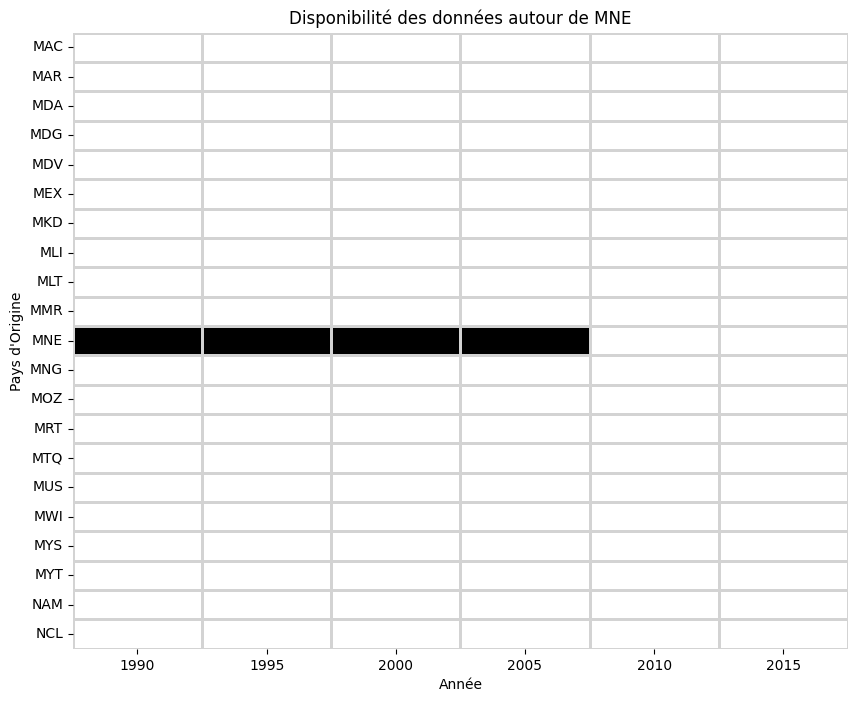

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

TARGET_COUNTRY = 'MNE'
WINDOW = 10

# Sélection des pays
pays_uniques = sorted(df_main['orig'].unique())
idx = pays_uniques.index(TARGET_COUNTRY)
subset = pays_uniques[max(0, idx - WINDOW) : min(len(pays_uniques), idx + WINDOW + 1)]

# Filtrage et Matrice
df_zoom = df_main[df_main['orig'].isin(subset)]
presence = pd.crosstab(df_zoom['orig'], df_zoom['year0'])

# Graphique
plt.figure(figsize=(10, 8))
sns.heatmap(presence > 0, cbar=False, cmap="binary_r", linewidths=1, linecolor='lightgray', vmin=0, vmax=1)
plt.title(f"Disponibilité des données autour de {TARGET_COUNTRY}")
plt.xlabel("Année")
plt.ylabel("Pays d'Origine")
plt.yticks(rotation=0)
plt.show()

Pays avec données manquantes: SRB en 1990-2000; SSD en 1990-2005; SDN en 1990-2000; MNE en 1990-2005; CUW en 1990-2005. 
Environ 7200 lignes perdues. 
199*199*6 - 7200= 230406. Il reste 230406-229350=1056 lignes disparues à élucider. 

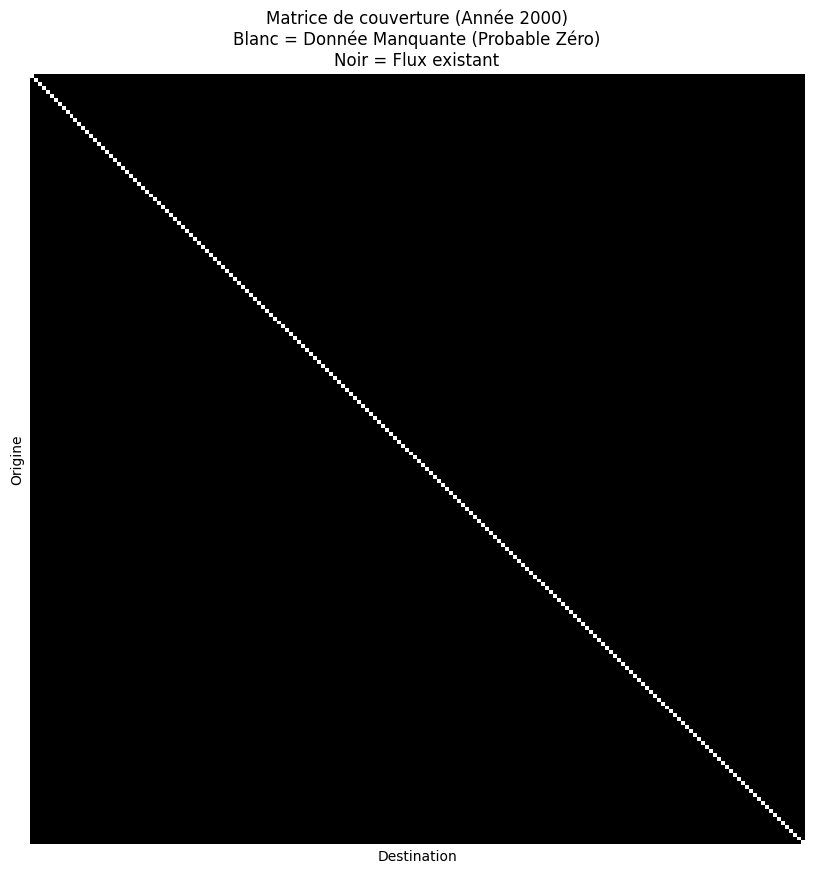

Taux de remplissage de la matrice en 2000 : 99.48%


In [50]:


# 1. On prend une année au milieu (2000)
df_2000 = df_main[df_main['year0'] == 2000]

# 2. On crée la matrice Origine x Destination
# Si un couple existe, on met 1, sinon c'est vide (NaN)
matrix_2000 = df_2000.pivot(index='orig', columns='dest', values='flow')

# 3. On transforme en binaire pour le visuel : Présent vs Absent
# .notnull() va mettre True si la ligne existe, False si elle manque
sparsity = matrix_2000.notnull()

# 4. Le Graphique
plt.figure(figsize=(10, 10))
sns.heatmap(sparsity, cbar=False, cmap="binary", xticklabels=False, yticklabels=False)
plt.title("Matrice de couverture (Année 2000)\nBlanc = Donnée Manquante (Probable Zéro)\nNoir = Flux existant")
plt.xlabel("Destination")
plt.ylabel("Origine")
plt.show()

# 5. Calcul du taux de remplissage exact pour 2000
fill_rate = sparsity.sum().sum() / (sparsity.shape[0] * sparsity.shape[1])
print(f"Taux de remplissage de la matrice en 2000 : {fill_rate:.2%}")

In [51]:




# 1. IDENTIFIER LES LIGNES SANS PIB
missing_gdp = df_main[df_main['gdp_o'].isna()]

print(f"--- DIAGNOSTIC IMPACT PIB ---")
print(f"Lignes sans PIB Origine : {len(missing_gdp)} sur {len(df_main)} ({len(missing_gdp)/len(df_main):.1%})")

# 2. QUI SONT LES COUPABLES ?
# On compte combien d'années manquent par pays
suspects = missing_gdp.groupby('orig')['year0'].nunique().sort_values(ascending=False)

print("\n--- TOP 10 PAYS SANS PIB (Nombre d'années manquantes sur 6) ---")
print(suspects.head(15))

# 3. EST-CE GRAVE ? (VOLUME DE MIGRANTS PERDUS)
# On compare le total des flux migratoires dans les lignes sans PIB vs le total mondial
total_flow_world = df_main['flow'].sum()
total_flow_lost  = missing_gdp['flow'].sum()

print("\n--- IMPACT RÉEL SUR LA PRÉDICTION ---")
print(f"Flux Total Mondial (Migrants) : {total_flow_world:,.0f}")
print(f"Flux concerné par les PIB manquants : {total_flow_lost:,.0f}")
print(f"PERTE EN VOLUME DE MIGRANTS : {total_flow_lost / total_flow_world:.2%}")

# 4. ANALYSE TEMPORELLE (Est-ce que c'est juste 1990 ?)
print("\n--- RÉPARTITION PAR ANNÉE (Lignes manquantes) ---")
print(missing_gdp['year0'].value_counts().sort_index())

--- DIAGNOSTIC IMPACT PIB ---
Lignes sans PIB Origine : 11090 sur 229350 (4.8%)

--- TOP 10 PAYS SANS PIB (Nombre d'années manquantes sur 6) ---
orig
ESH    6
GLP    6
GUF    6
MYT    6
PRK    6
REU    6
MTQ    6
GUM    3
VIR    3
AFG    2
ERI    2
EST    1
LTU    1
MOZ    1
LVA    1
Name: year0, dtype: int64

--- IMPACT RÉEL SUR LA PRÉDICTION ---
Flux Total Mondial (Migrants) : 482,102,792
Flux concerné par les PIB manquants : 3,792,273
PERTE EN VOLUME DE MIGRANTS : 0.79%

--- RÉPARTITION PAR ANNÉE (Lignes manquantes) ---
year0
1990    3088
1995    1930
2000    1737
2005    1365
2010    1386
2015    1584
Name: count, dtype: int64


problème alphabétique!!! probablement dans le chargement de Gravity qui fait >1 Giga.

In [52]:
# On définit les blocs thématiques tels qu'on les a décrits dans le rapport
groups = {
    "Identifiants & Flux": ['orig', 'dest', 'flow', 'year0'],
    "Démographie (ONU)": ['P_it', 'PSR_i', 'IMR_it'],
    "Urbanisation": ['urban_it', 'urban_jt'],
    "Géographie (CEPII)": ['D_ij', 'LB_ij'],
    "Économie retardée": ['gdp_o_lag'] 
}

def check_completeness(df, groups):
    total_rows = len(df)
    results = []
    
    for label, cols in groups.items():
        # On vérifie la présence des colonnes dans le DF pour éviter les erreurs
        existing_cols = [c for c in cols if c in df.columns]
        
        if not existing_cols:
            results.append([label, "Variables non trouvées", 0, "0.0 %"])
            continue
            
        # On calcule le nombre de lignes où TOUTES les variables du bloc sont présentes
        # C'est important car en économétrie, si une seule manque, la ligne saute.
        non_null_count = df[existing_cols].dropna().shape[0]
        pct = (non_null_count / total_rows) * 100
        
        results.append([
            label, 
            ", ".join(existing_cols), 
            non_null_count, 
            f"{pct:.2f} %"
        ])
    
    # Création du tableau final
    summary_df = pd.DataFrame(results, columns=[
        "Bloc thématique", "Variables testées", "Lignes complètes", "Taux de remplissage"
    ])
    
    return summary_df

# Utilisation (en supposant que ton DataFrame s'appelle df)
# stats_tableau = check_completeness(df, groups)
# print(stats_tableau)

In [53]:
stats_tableau = check_completeness(df_main, groups)
stats_tableau

,Bloc thématique,Variables testées,Lignes complètes,Taux de remplissage
0,Identifiants & Flux,"orig, dest, flow, year0",229350,100.00 %
1,Démographie (ONU),"P_it, PSR_i, IMR_it",229350,100.00 %
2,Urbanisation,"urban_it, urban_jt",215490,93.96 %
3,Géographie (CEPII),"D_ij, LB_ij",209814,91.48 %
4,Économie retardée,gdp_o_lag,214593,93.57 %


In [55]:
all_features = ['flow', 'P_it', 'P_jt', 'D_ij', 'urban_it', 'gdp_o_lag']
final_sample_size = df_main[all_features].dropna().shape[0]

print(f"Nombre de lignes pour l'estimation finale : {final_sample_size}")
print(f"Taux de survie total : {(final_sample_size / 229350) * 100:.2f} %")

Nombre de lignes pour l'estimation finale : 198263
Taux de survie total : 86.45 %
